In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

c:\Users\CARNIVAL\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.stats import gaussian_kde


## Data Explortion and Preprocessing

In [2]:
original_data = pd.read_csv('./CC GENERAL.csv')

# Let's look at the data
original_data.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
# Investigate the columns types

original_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [4]:
# Check the missing values

print(original_data.isna().sum())

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


In [5]:
# Investigate the missing values in "CREDIT_LIMIT" column

original_data[original_data['CREDIT_LIMIT'].isna()]

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
5203,C15349,18.400472,0.166667,0.0,0.0,0.0,186.853063,0.0,0.0,0.0,0.166667,1,0,NaN,9.040017,14.418723,0.0,6


The `CREDIT_LIMIT` missing for this customer because he/she did not make any purchase before. In such case, we can train an ML like **KNN** to impute these values based on the most similar customers who made purchases before. But, in this case it's only one customer in the dataset that has no `CREDIT_LIMIT`, so we just may impute it with the median for easiness.

In [6]:
# Impute the missing values in "CREDIT_LIMIT" column with median

original_data['CREDIT_LIMIT'] = original_data['CREDIT_LIMIT'].fillna(original_data['CREDIT_LIMIT'].median())

In [7]:
# Investigate the missing values in "MINIMUM_PAYMENTS" column

original_data[original_data['MINIMUM_PAYMENTS'].isna()].head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
3,C10004,1666.670542,0.636364,1499.0,1499.0,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.0,12
45,C10047,2242.311686,1.000000,437.0,97.0,340.0,184.648692,0.333333,0.083333,0.333333,0.166667,2,5,2400.0,0.000000,NaN,0.0,12
47,C10049,3910.111237,1.000000,0.0,0.0,0.0,1980.873201,0.000000,0.000000,0.000000,0.500000,7,0,4200.0,0.000000,NaN,0.0,12
54,C10056,6.660517,0.636364,310.0,0.0,310.0,0.000000,0.666667,0.000000,0.666667,0.000000,0,8,1000.0,417.016763,NaN,0.0,12
55,C10057,1311.995984,1.000000,1283.9,1283.9,0.0,0.000000,0.250000,0.250000,0.000000,0.000000,0,6,6000.0,0.000000,NaN,0.0,12


In [8]:
# Look at the "PRC_FULL_PAYMENT" column for these customers

customers_with_missing_min_payment = original_data[original_data['MINIMUM_PAYMENTS'].isna()]
print(customers_with_missing_min_payment['PRC_FULL_PAYMENT'].value_counts())

PRC_FULL_PAYMENT
0.0    313
Name: count, dtype: int64


After investigation, the missing values in the `MINIMUM_PAYMENTS` column appear to belong to customers who either made no purchases or made purchases but did not pay toward them. This can be verified by examining the `PRC_FULL_PAYMENT` column, which has a value of zero for those customers. So, we can impute the missing values in this column by zero.

In [9]:
# Impute the missing values in 'MINIMUM_PAYMENTS' by zero

original_data['MINIMUM_PAYMENTS'] = original_data['MINIMUM_PAYMENTS'].fillna(0)

In [10]:
# Check if there are duplicates

original_data[original_data.duplicated()]

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE


In [11]:
# Drop 'CUST_ID' column

original_data = original_data.drop(columns=['CUST_ID'])

In [12]:
original_data.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,0.000000,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [13]:
# Get summary about columns

original_data.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.282473,1733.143852,833.983453,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.646702,2895.063757,2335.989918,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.000000,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,163.028164,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,289.628402,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,788.713501,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


This descriptive statistics summary provides key insights into our data, such as whether the numerical columns (features) are normally distributed or skewed.

Text(0.5, 0.98, "Balance Related Columns' Distributions")

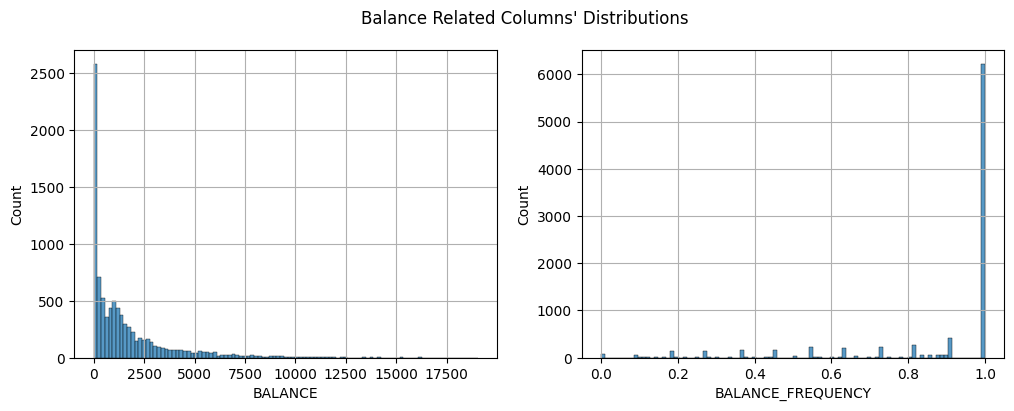

In [14]:
# Let's visulaize the numerical columns' distributions
# I will group each set of related columns together in a single figure.

# 1. Balance related columns
balance_columns = ['BALANCE', 'BALANCE_FREQUENCY']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(original_data, x=balance_columns[0], ax=axes[0])
axes[0].grid()

sns.histplot(original_data, x=balance_columns[1], ax=axes[1])
axes[1].grid()

fig.suptitle("Balance Related Columns' Distributions")

Text(0.5, 0.98, "Purchase Related Columns' Distributions")

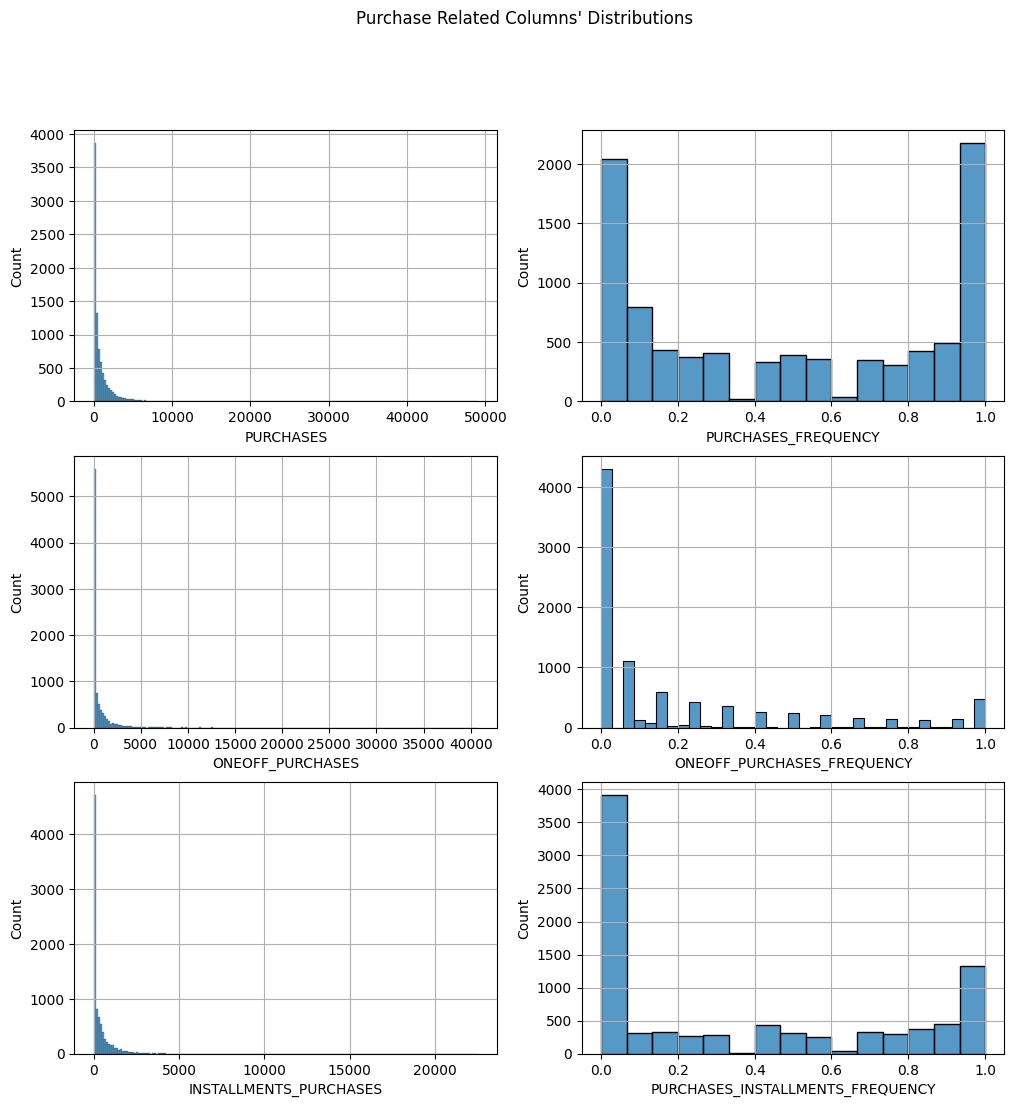

In [15]:
# 2. Purchase related columns
purchase_columns = ['PURCHASES', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES', 'ONEOFF_PURCHASES_FREQUENCY',
                    'INSTALLMENTS_PURCHASES', 'PURCHASES_INSTALLMENTS_FREQUENCY']
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
sns.histplot(original_data, x=purchase_columns[0], ax=axes[0, 0])
axes[0, 0].grid()

sns.histplot(original_data, x=purchase_columns[1], ax=axes[0, 1])
axes[0, 1].grid()

sns.histplot(original_data, x=purchase_columns[2], ax=axes[1, 0])
axes[1, 0].grid()

sns.histplot(original_data, x=purchase_columns[3], ax=axes[1, 1])
axes[1, 1].grid()

sns.histplot(original_data, x=purchase_columns[4], ax=axes[2, 0])
axes[2, 0].grid()

sns.histplot(original_data, x=purchase_columns[5], ax=axes[2, 1])
axes[2, 1].grid()

fig.suptitle("Purchase Related Columns' Distributions")

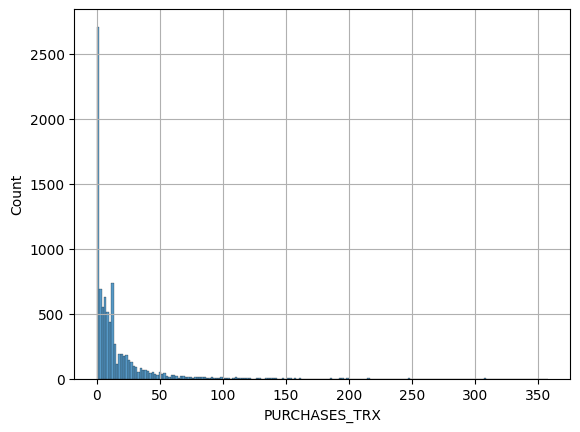

In [16]:
sns.histplot(original_data, x='PURCHASES_TRX')
plt.grid()

Text(0.5, 0.98, "Cash Advance Related Columns' Distributions")

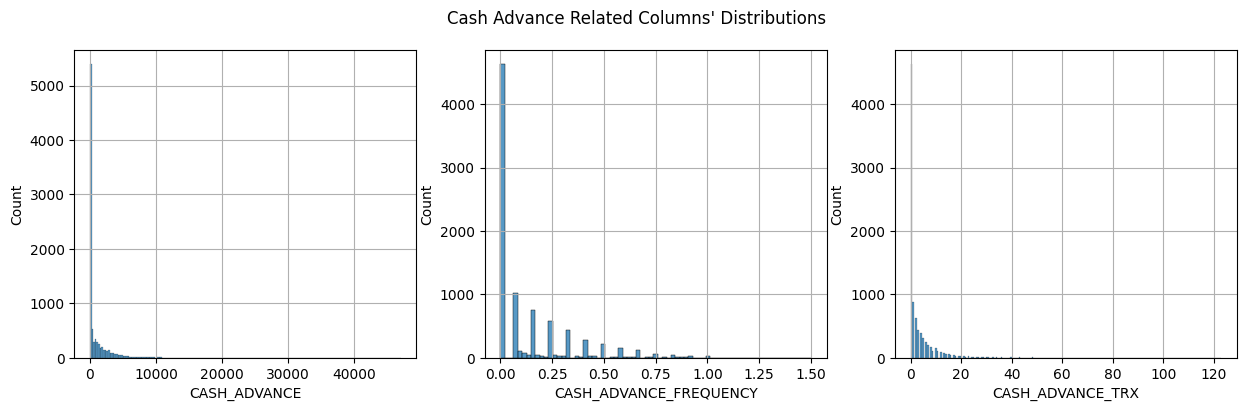

In [17]:
# 3. Cash advance related columns
cash_columns = ['CASH_ADVANCE', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(original_data, x=cash_columns[0], ax=axes[0])
axes[0].grid()

sns.histplot(original_data, x=cash_columns[1], ax=axes[1])
axes[1].grid()

sns.histplot(original_data, x=cash_columns[2], ax=axes[2])
axes[2].grid()

fig.suptitle("Cash Advance Related Columns' Distributions")

Text(0.5, 0.98, "Payment Related Columns' Distributions")

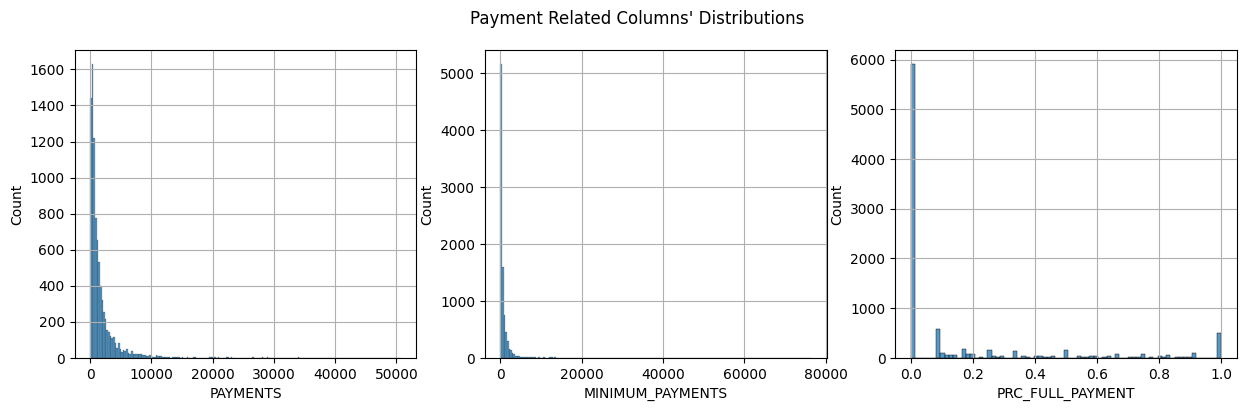

In [18]:
# 4. Payment related columns
payment_columns = ['PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(original_data, x=payment_columns[0], ax=axes[0])
axes[0].grid()

sns.histplot(original_data, x=payment_columns[1], ax=axes[1])
axes[1].grid()

sns.histplot(original_data, x=payment_columns[2], ax=axes[2])
axes[2].grid()

fig.suptitle("Payment Related Columns' Distributions")

Text(0.5, 0.98, "Credit Limit and Tenure Columns' Distributions")

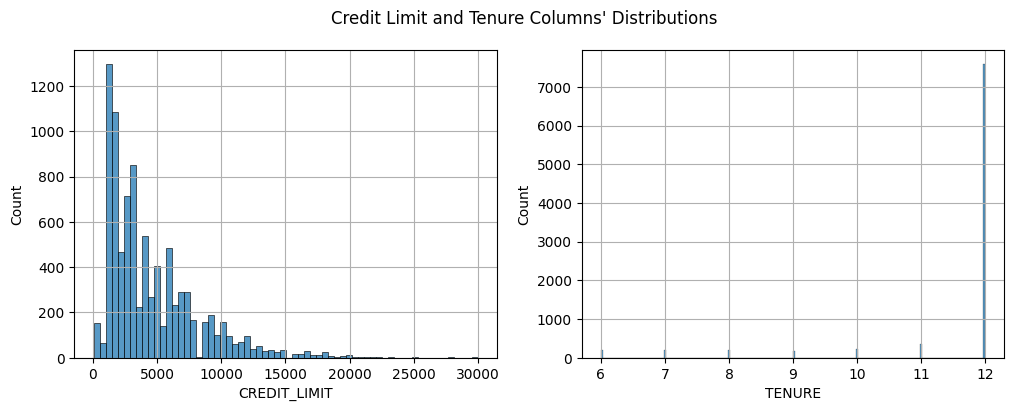

In [19]:
# 5. "CREDIT_LIMIT" and "TENURE" columns
last_columns = ['CREDIT_LIMIT', 'TENURE']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(original_data, x=last_columns[0], ax=axes[0])
axes[0].grid()

sns.histplot(original_data, x=last_columns[1], ax=axes[1])
axes[1].grid()

fig.suptitle("Credit Limit and Tenure Columns' Distributions")

We can apply the logarithm transformation to the right skewed columns. Frequency and precentage columns do not need to be transformed, since their range of values is small. Also, `TENURE` will not be transformed as it's a discrete column and its trange is small (6 - 12)

In [20]:
transformation_columns = original_data.columns.to_list()
unneeded_columns = ['BALANCE_FREQUENCY', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
                    'CASH_ADVANCE_FREQUENCY', 'PRC_FULL_PAYMENT', 'TENURE']

for col in unneeded_columns:
  transformation_columns.remove(col)

print(transformation_columns)

['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS']


In [21]:
# Transform every column in transformation_columns using logarithm
transformed_data = original_data.copy()


for col in transformation_columns:
  transformed_data[col] += 1e-8     # Add a small value to avoid numerical instability (e.g., np.log(0))
  transformed_data[col] = np.log(transformed_data[col])

array([[<Axes: title={'center': 'BALANCE'}>,
        <Axes: title={'center': 'PURCHASES'}>,
        <Axes: title={'center': 'ONEOFF_PURCHASES'}>],
       [<Axes: title={'center': 'INSTALLMENTS_PURCHASES'}>,
        <Axes: title={'center': 'CASH_ADVANCE'}>,
        <Axes: title={'center': 'CASH_ADVANCE_TRX'}>],
       [<Axes: title={'center': 'PURCHASES_TRX'}>,
        <Axes: title={'center': 'CREDIT_LIMIT'}>,
        <Axes: title={'center': 'PAYMENTS'}>],
       [<Axes: title={'center': 'MINIMUM_PAYMENTS'}>, <Axes: >, <Axes: >]],
      dtype=object)

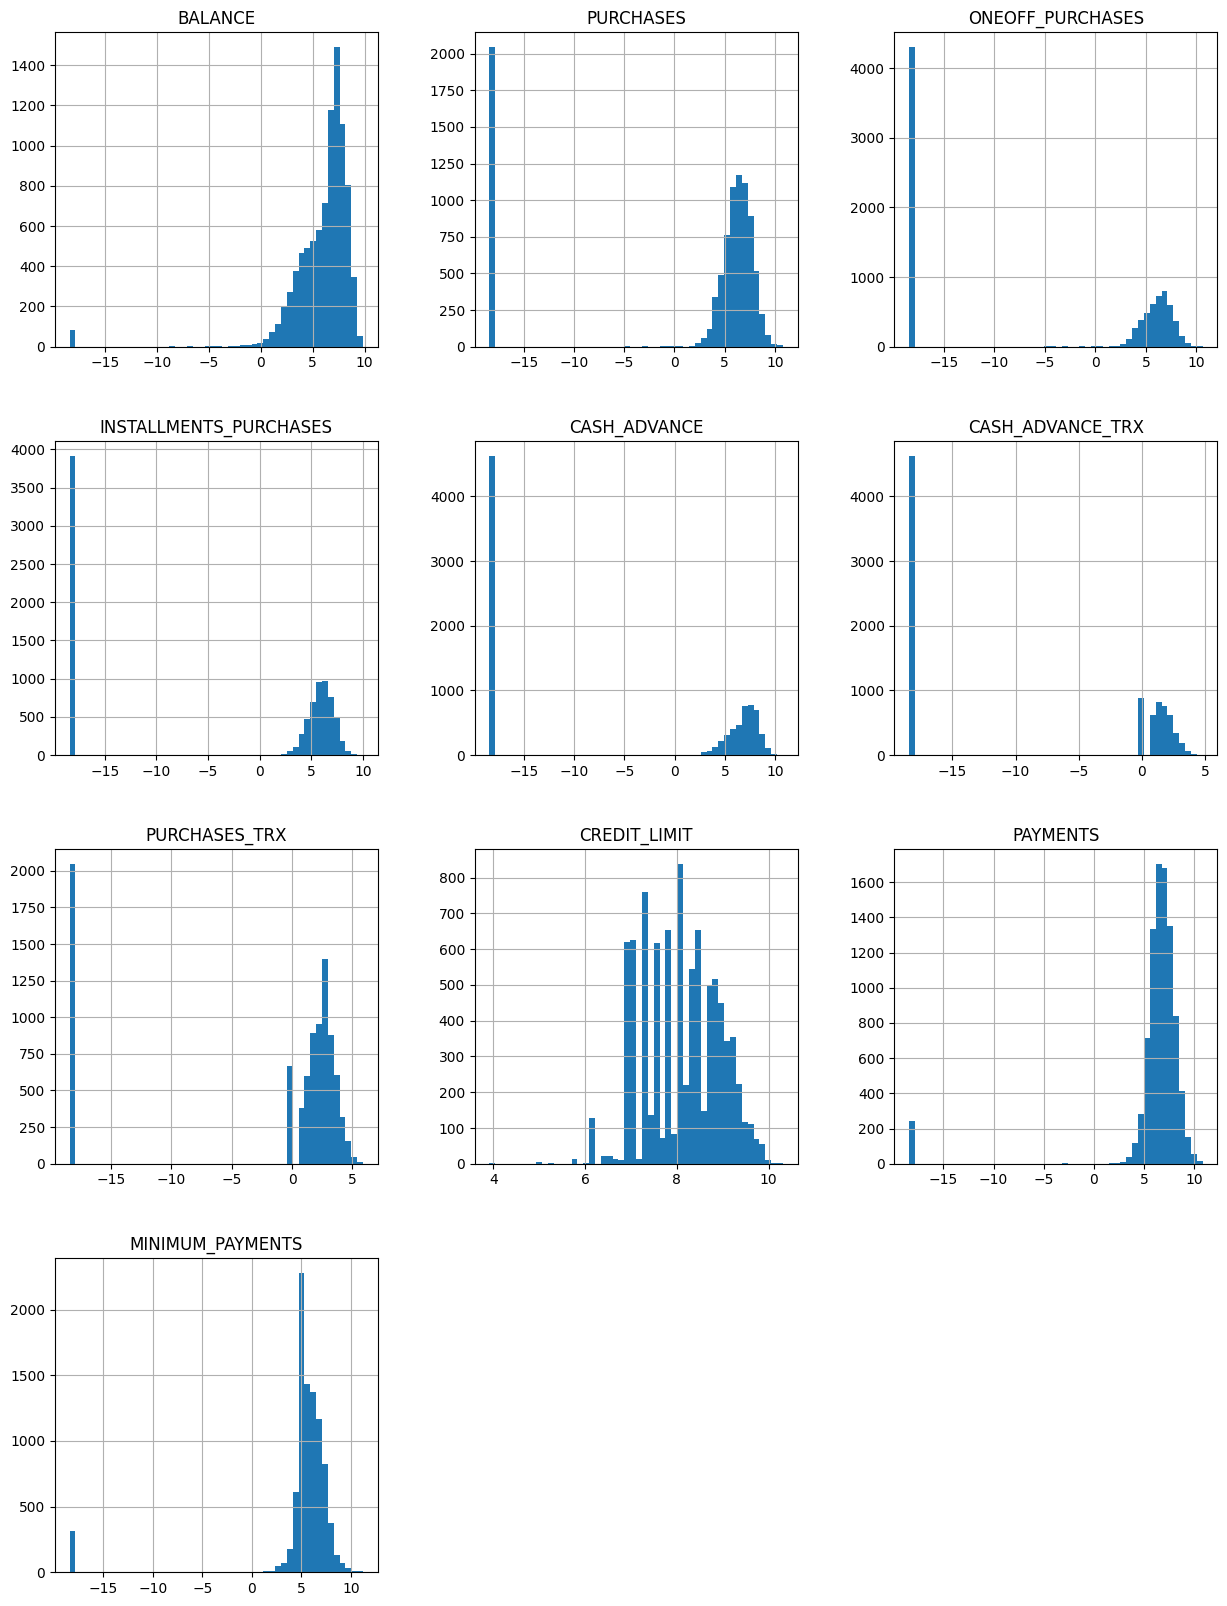

In [22]:
# Visualize the transformed columns

transformed_data[transformation_columns].hist(figsize=(15, 20), bins=50)

After the transformation, the data becomes normally distributed, which will likely make it easier for the model to cluster the segments.

## Modeling

In [23]:
transformed_data.shape

(8950, 17)

The dataset contains 17 features. We can attempt to reduce its dimensionality using **t-SNE** and visualize it in 2D. This will help us gain insights into the potential number of clusters we should apply to the data.

In [24]:
from sklearn.manifold import TSNE

# Get a random sample of 10% the data
sample_size = round(0.1 * transformed_data.shape[0])
sample_data = transformed_data.sample(sample_size, random_state=42)

# Apply t-SNE
tsne = TSNE(n_components=2, perplexity=40, random_state=42, init='pca', learning_rate='auto')
tsne_results = tsne.fit_transform(sample_data)

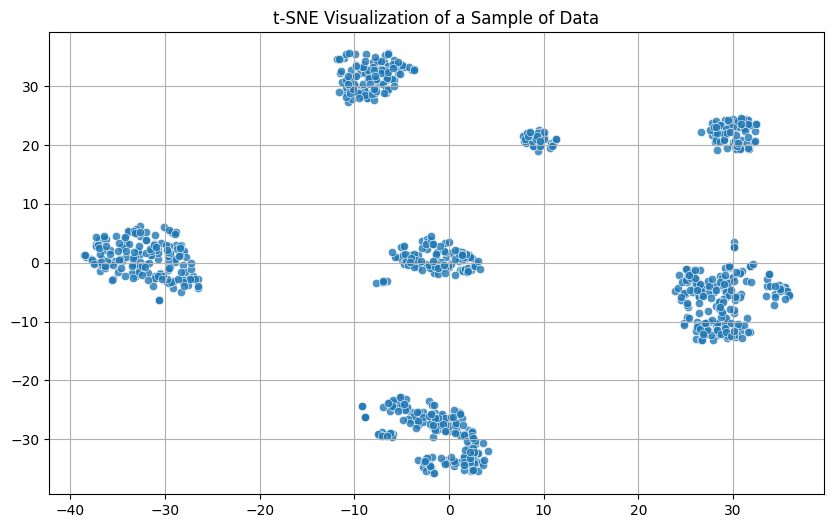

In [25]:
# Plot the results
plt.figure(figsize=(10, 6))
sns.scatterplot(x=tsne_results[:, 0], y=tsne_results[:, 1], alpha=0.8)
plt.title('t-SNE Visualization of a Sample of Data')
plt.grid()
plt.show()

According to the visualization, we can assume that there are 7 clusters (customer segments).

In [26]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=7, random_state=42)
gmm.fit(transformed_data)

clusters = gmm.predict(transformed_data)

In [27]:
clusters = pd.Series(clusters, name='Clusters')

In [28]:
tsne = TSNE(n_components=2, perplexity=40, random_state=42, init='pca', learning_rate='auto')
tsne_results = tsne.fit_transform(transformed_data)

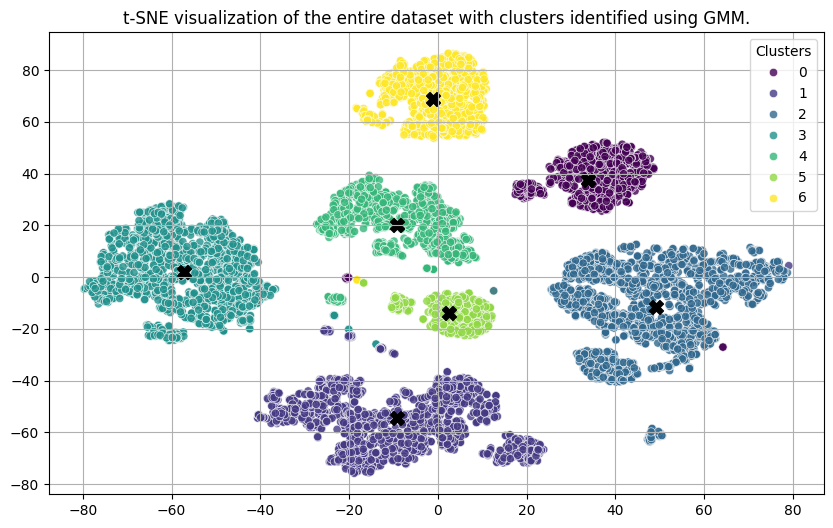

In [49]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=tsne_results[:, 0], y=tsne_results[:, 1], hue=clusters, alpha=0.8, palette='viridis')

for k in range(7):
    clusters_points = tsne_results[clusters == k]
    centroid = clusters_points.mean(axis=0)
    plt.scatter(x=centroid[0], y=centroid[1], color='black', s=100, marker='X')

plt.title('t-SNE visualization of the entire dataset with clusters identified using GMM.')
plt.grid()
plt.show()

Overall, the segments appear to be well-defined. Although there may be a few data points that are potentially mis clustered, we can further explore the characteristics of each segment individually to verify if each segment has the same characteristics.

## Investigate Results

In [ ]:
original_data_with_clusters = pd.concat([original_data, clusters], axis=1)

original_data_with_clusters.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Clusters
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,1
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,4
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,0.000000,0.000000,12,0
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,4


In [ ]:
original_data_with_clusters.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE', 'Clusters'],
      dtype='object')

/tmp/ipython-input-64955268.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(original_data_with_clusters, x='Clusters', y=targets[counter], estimator='mean', palette='viridis', ax=axes[row, col])
/tmp/ipython-input-64955268.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(original_data_with_clusters, x='Clusters', y=targets[counter], estimator='mean', palette='viridis', ax=axes[row, col])
/tmp/ipython-input-64955268.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(original_data_with_clusters, x='Clusters', y=targets[counter], est

Text(0.5, 0.98, 'Analysis of each cluster')

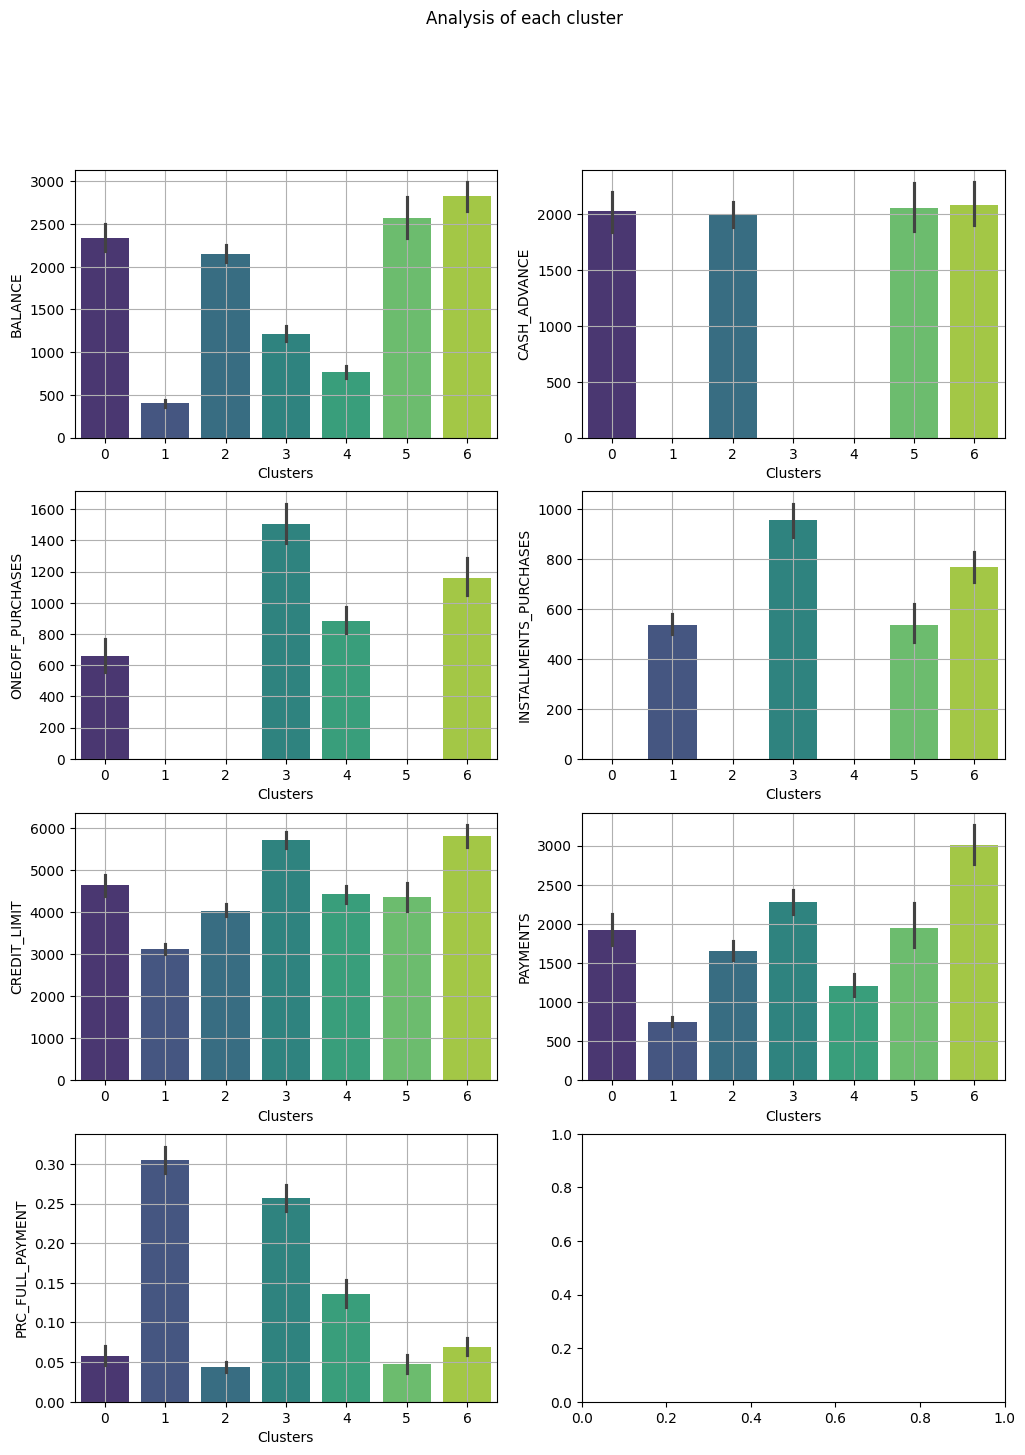

In [ ]:
# Visualize the ["BALANCE", "CASH_ADVANCE", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES", "CREDIT_LIMIT", "PAYMENTS", "PRC_FULL_PAYMENT"]
# for each cluster

targets = ["BALANCE", "CASH_ADVANCE", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES", "CREDIT_LIMIT", "PAYMENTS", "PRC_FULL_PAYMENT"]
rows = 4
cols = 2
fig, axes = plt.subplots(rows, cols, figsize=(12, 16))

index = 0
for row in range(rows):
  for col in range(cols):
    if (row == 3) and (col == 1):
      break
    sns.barplot(original_data_with_clusters, x='Clusters', y=targets[index], estimator='mean', palette='viridis', ax=axes[row, col])
    axes[row, col].grid()
    index += 1

fig.suptitle('Analysis of each cluster')

## Customer Segmentation Profiles

Based on behavioral and financial patterns, customers were segmented into **7 distinct clusters**. The segmentation considers balance behavior, cash advance usage, one-off purchases, installment purchases, credit limit, payments, and percent of full payment.

---

### 🔴 Cluster 0 – Cash + Transaction Revolvers
- **Balance:** High  
- **Cash Advance:** High  
- **One-off Purchases:** Middle  
- **Installment Purchases:** Zero  
- **Credit Limit:** ~4600  
- **Payments:** Middle  
- **Percent Full Payment:** Low  

**Profile Interpretation:**  
Customers who rely on cash advances while also making transactional purchases. They tend to revolve balances and do not frequently pay in full.

---

### 🟢 Cluster 1 – Low-Activity Installment Planners
- **Balance:** Low  
- **Cash Advance:** Zero  
- **One-off Purchases:** Zero  
- **Installment Purchases:** Middle  
- **Credit Limit:** ~3100  
- **Payments:** Low  
- **Percent Full Payment:** High  

**Profile Interpretation:**  
Low-usage customers who occasionally use installment plans and generally pay in full. Low risk, low profitability segment.

---

### 🔴 Cluster 2 – Pure Cash Borrowers
- **Balance:** High  
- **Cash Advance:** High  
- **One-off Purchases:** Zero  
- **Installment Purchases:** Zero  
- **Credit Limit:** ~4000  
- **Payments:** Middle  
- **Percent Full Payment:** Low  

**Profile Interpretation:**  
Customers using the credit card primarily for cash advances with no purchase activity. High revolving behavior and elevated credit risk.

---

### 🔵 Cluster 3 – Premium Full-Pay Users
- **Balance:** Middle  
- **Cash Advance:** Zero  
- **One-off Purchases:** High  
- **Installment Purchases:** High  
- **Credit Limit:** ~5700  
- **Payments:** High  
- **Percent Full Payment:** High  

**Profile Interpretation:**  
Highly engaged customers using both purchase types while consistently paying in full. Low risk and high strategic value.

---

### 🟣 Cluster 4 – Light One-Off Users
- **Balance:** Low  
- **Cash Advance:** Zero  
- **One-off Purchases:** Middle  
- **Installment Purchases:** Zero  
- **Credit Limit:** ~4400  
- **Payments:** Middle  
- **Percent Full Payment:** Middle  

**Profile Interpretation:**  
Occasional transactional users with moderate payment behavior. Stable but not highly profitable.

---

### 🟠 Cluster 5 – Installment-Dependent Revolvers
- **Balance:** High  
- **Cash Advance:** High  
- **One-off Purchases:** Zero  
- **Installment Purchases:** Middle  
- **Credit Limit:** ~4300  
- **Payments:** Middle  
- **Percent Full Payment:** Low  

**Profile Interpretation:**  
Customers heavily dependent on installment plans and cash advances, with revolving balances. Moderate-to-high risk segment.

---

### 🔴 Cluster 6 – Heavy Multi-Product Revolvers
- **Balance:** High  
- **Cash Advance:** High  
- **One-off Purchases:** High  
- **Installment Purchases:** High  
- **Credit Limit:** ~5800  
- **Payments:** High  
- **Percent Full Payment:** Low  

**Profile Interpretation:**  
Highly active across all products with strong payment amounts but low full-payment ratio. Profitable yet risk-sensitive segment.

---

## Summary

The 7 clusters reflect distinct customer behaviors across:
- Liquidity dependence (cash advance usage)
- Transactional spending (one-off purchases)
- Structured financing (installments)
- Payment discipline
- Credit exposure

This segmentation enables targeted risk management, marketing strategies, and profitability optimization.